In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
import os
os.listdir()


['retail_sales_dataset.csv',
 'Ipshit_Task1_EDA_Retail_Sales.ipynb',
 '.ipynb_checkpoints']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


# Initial Inspection Observation

- Dataset contains retail sales transaction data.
- Data types of all columns were examined.
- Missing values were checked to ensure data quality.
- Dataset is suitable for further exploratory data analysis.

In [5]:
# Descriptive Statistics

print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode().iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


# Descriptive Statistics Observation

- Mean and median values provide insights into the central tendency of numerical variables.
- Mode represents the most frequent values in the dataset.
- Standard deviation indicates the variability in the data.
- These statistics help understand customer purchasing patterns.
- 

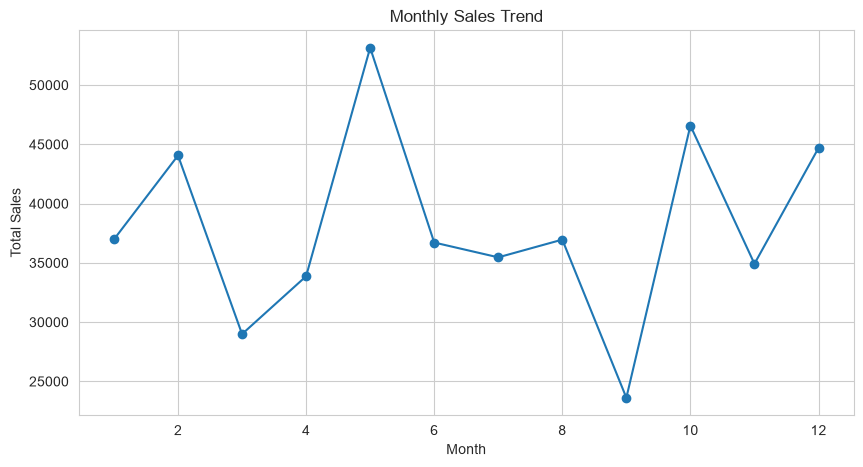

In [6]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create Month and Quarter columns
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Monthly Sales Trend Observation

- Monthly sales vary across the year.
- Some months generate higher revenue than others.
- Understanding monthly patterns helps businesses optimize inventory and marketing strategies.

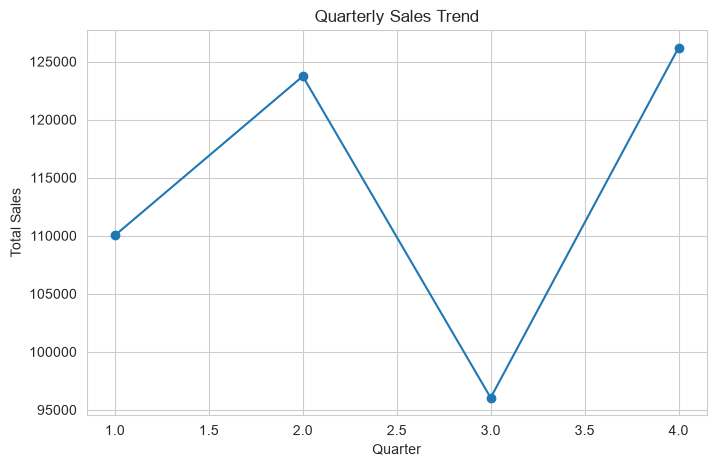

In [7]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(marker='o')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Quarterly Sales Trend Observation

- Quarterly analysis helps identify seasonal patterns.
- Revenue distribution across quarters provides insights into business performance.

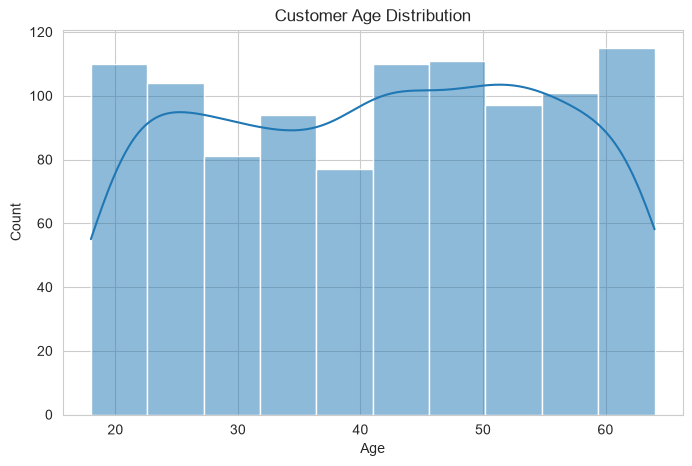

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Age Distribution Observation

- Customers belong to different age groups.
- The distribution helps identify the target customer segment.
- Age analysis is useful for personalized marketing strategies.

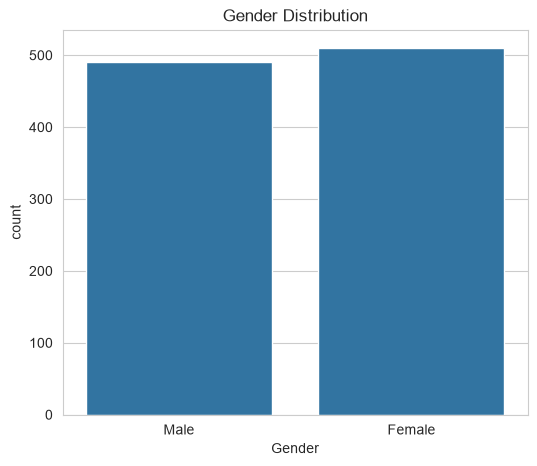

In [9]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Gender Distribution Observation

- The dataset contains both male and female customers.
- Gender analysis helps understand customer preferences and demographics.

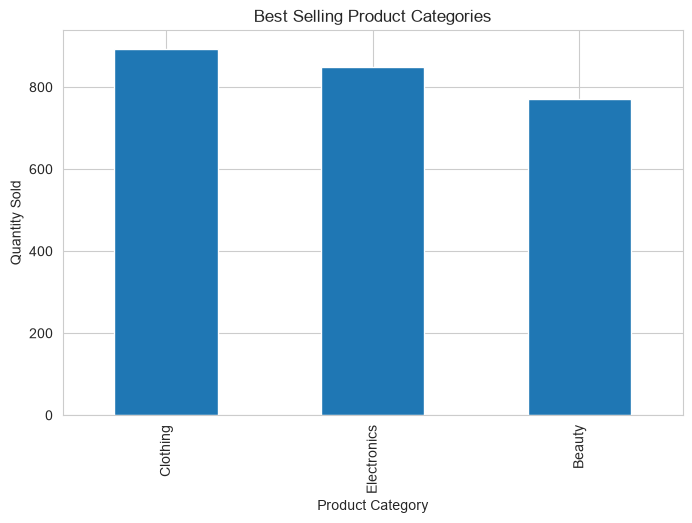

In [10]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title("Best Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.show()

# Product Analysis Observation

- Product categories contribute differently to total sales.
- Identifying high-selling categories helps optimize inventory management.
- Businesses can focus on top-performing categories for higher profitability.

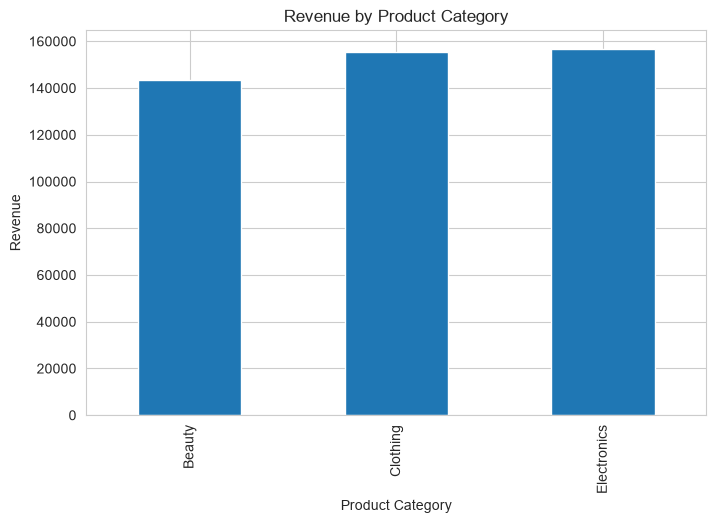

In [11]:
revenue_by_category = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))
revenue_by_category.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

# Revenue Analysis Observation

- Revenue contribution varies across product categories.
- High revenue categories should receive more marketing focus.
- Category-wise analysis helps in business decision-making.

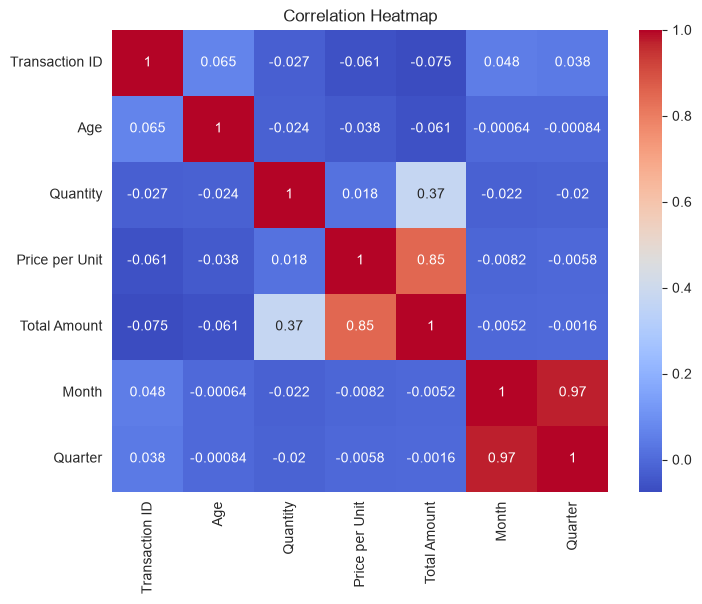

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation Heatmap Observation

- Correlation analysis shows relationships between numerical variables.
- Strong positive correlations indicate variables that increase together.
- Heatmaps help identify patterns useful for business decisions.

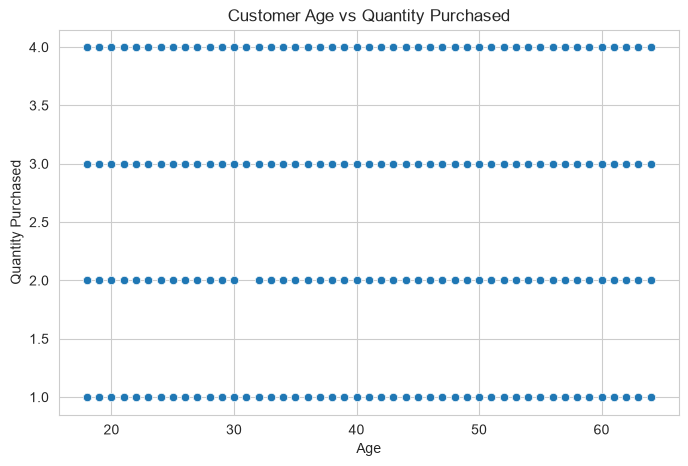

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Quantity', data=df)
plt.title("Customer Age vs Quantity Purchased")
plt.xlabel("Age")
plt.ylabel("Quantity Purchased")
plt.show()

# Additional Visualization Observation

- Customer age influences purchasing behaviour.
- Different age groups exhibit varying purchase quantities.
- Such insights help businesses target specific customer segments.

# Conclusion and Business Recommendations

1. Focus marketing campaigns on high-revenue product categories to maximize profitability.

2. Analyze seasonal trends and increase inventory during high-performing months and quarters.

3. Target specific customer age groups with personalized promotions to improve customer engagement and sales.